## 1. Import Data ##

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

preprocessed_df=pd.read_csv('UKBB_preprocessed.csv')
preprocessed_df.head()

,Broad_ID,gene1,gene2,gene3,VAF1,VAF2,VAF3,sex,CH_score,eid,...,MRV,MspCV,immret,hiscatret,age,year_of_assessment,year_MN,MN_type,CHRS,MN
0,3463778,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,4726860.0,...,111.23,82.09,0.211,0.014,42.000000,2009.666667,NaN,NaN,0.0,0
1,2821197,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,1633945.0,...,104.46,81.47,0.214,0.009,47.000000,2009.666667,NaN,NaN,0.0,0
2,1514525,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,4596360.0,...,106.56,86.68,0.228,0.005,52.416667,2009.666667,NaN,NaN,0.0,0
3,2491905,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,3143018.0,...,111.75,83.24,0.360,0.030,65.750000,2009.666667,NaN,NaN,0.0,0
4,3250377,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,2254568.0,...,107.37,82.90,0.271,0.021,57.000000,2009.666667,NaN,NaN,0.0,0


In [2]:
len(preprocessed_df[preprocessed_df['CHRS']==0])

432699

### 1.1 Create feature column for giant platelets ###

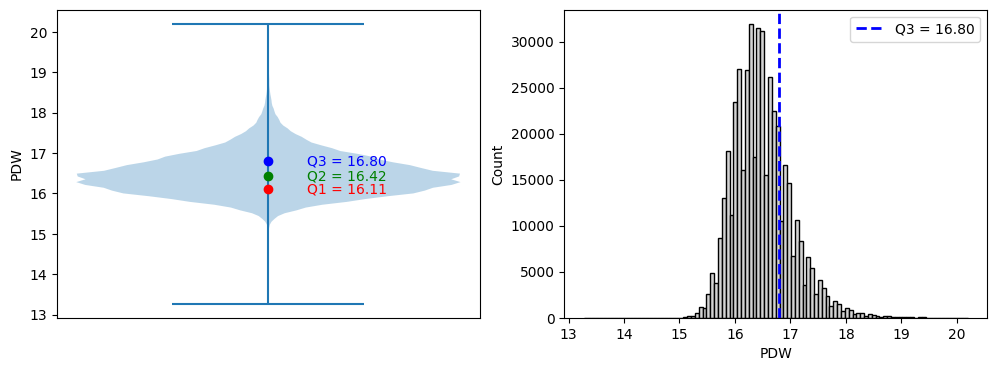

In [6]:
from scipy import stats
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Calculate quartiles
Q1 = preprocessed_df['PDW'].quantile(0.25)
Q2 = preprocessed_df['PDW'].quantile(0.50)
Q3 = preprocessed_df['PDW'].quantile(0.75)


# --- Boxplot ---
#axes[0].boxplot(preprocessed_df['PDW'], vert=True, patch_artist=True)
axes[0].violinplot(preprocessed_df['PDW'], showmeans=False, showmedians=False)
axes[0].scatter(1, Q1, color='red', zorder=3)
axes[0].scatter(1, Q2, color='green', zorder=3)
axes[0].scatter(1, Q3, color='blue', zorder=3)

# Annotate quartiles
axes[0].text(1.05, Q1, f"Q1 = {Q1:.2f}", color='red', va='center')
axes[0].text(1.05, Q2, f"Q2 = {Q2:.2f}", color='green', va='center')
axes[0].text(1.05, Q3, f"Q3 = {Q3:.2f}", color='blue', va='center')

# Remove x-axis tick and label
axes[0].set_xticks([])
axes[0].set_xlabel("")
axes[0].set_ylabel("PDW")

# --- Histogram ---
axes[1].hist(preprocessed_df['PDW'], bins=100, color='lightgray', edgecolor='black')
axes[1].axvline(Q3, color='blue', linestyle='--', linewidth=2, label=f"Q3 = {Q3:.2f}")
axes[1].set_xlabel("PDW")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.savefig('figures/giantplt.png',bbox_inches='tight',dpi=300)
plt.savefig('figures/giantplt.pdf',bbox_inches='tight')
plt.savefig('figures/giantplt.svg',bbox_inches='tight')
plt.show()

In [24]:
preprocessed_df['giant_plt']=np.where(preprocessed_df['PDW']>16.8,1,0)
preprocessed_df['giant_plt'].value_counts()

giant_plt
0    355578
1    105998
Name: count, dtype: int64

In [25]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461576 entries, 0 to 461575
Data columns (total 40 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Broad_ID            461576 non-null  int64  
 1   gene1               29113 non-null   object 
 2   gene2               1987 non-null    object 
 3   gene3               202 non-null     object 
 4   VAF1                29113 non-null   float64
 5   VAF2                1987 non-null    float64
 6   VAF3                202 non-null     float64
 7   sex                 461576 non-null  int64  
 8   CH_score            461576 non-null  float64
 9   eid                 461576 non-null  float64
 10  WBC                 461576 non-null  float64
 11  RBC                 461576 non-null  float64
 12  Hbconc              461576 non-null  float64
 13  haematocrit         461576 non-null  float64
 14  MCV                 461576 non-null  float64
 15  MCHb                461576 non-nul

## 2. Classification ##

#### 2.1 Classification Labels - 4 classes ####

In [4]:
df_CH=preprocessed_df.copy()

df_CH.loc[:,'MN']=np.where(df_CH['year_MN'].notnull(),1,0)

df_ar=df_CH.to_numpy()
rows,columns=df_ar.shape
print(rows,columns)

# Assign condition for CH 

CH0=np.where(df_CH['CH_score']==0)
CH1=np.where((df_CH['CH_score']>0) & (df_CH['CH_score']<=4))
CH2=np.where((df_CH['CH_score']>4) & (df_CH['MN']==0))
CH3=np.where((df_CH['CH_score']>4) & (df_CH['MN']==1))

CH_ar=np.zeros((rows,))
CH_ar[CH0]=0
CH_ar[CH1]=1
CH_ar[CH2]=2
CH_ar[CH3]=3

df_CH['CH']=CH_ar

df_CH.head()

461576 39


,Broad_ID,gene1,gene2,gene3,VAF1,VAF2,VAF3,sex,CH_score,eid,...,MspCV,immret,hiscatret,age,year_of_assessment,year_MN,MN_type,CHRS,MN,CH
0,3463778,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,4726860.0,...,82.09,0.211,0.014,42.000000,2009.666667,NaN,NaN,0.0,0,0.0
1,2821197,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,1633945.0,...,81.47,0.214,0.009,47.000000,2009.666667,NaN,NaN,0.0,0,0.0
2,1514525,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,4596360.0,...,86.68,0.228,0.005,52.416667,2009.666667,NaN,NaN,0.0,0,0.0
3,2491905,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,3143018.0,...,83.24,0.360,0.030,65.750000,2009.666667,NaN,NaN,0.0,0,0.0
4,3250377,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,2254568.0,...,82.90,0.271,0.021,57.000000,2009.666667,NaN,NaN,0.0,0,0.0


#### 2.2.2 Classification Labels - 3 classes ####

In [26]:
df_CH=preprocessed_df.copy()

df_CH.loc[:,'MN']=np.where(df_CH['year_MN'].notnull(),1,0)

df_ar=df_CH.to_numpy()
rows,columns=df_ar.shape
print(rows,columns)

# Assign condition for CH 

CH0=np.where(df_CH['CH_score']<=4)
CH1=np.where((df_CH['CH_score']>4) & (df_CH['MN']==0))
CH2=np.where((df_CH['CH_score']>4) & (df_CH['MN']==1))

CH_ar=np.zeros((rows,))
CH_ar[CH0]=0
CH_ar[CH1]=1
CH_ar[CH2]=2

df_CH['CH']=CH_ar

df_CH.head()

461576 40


,Broad_ID,gene1,gene2,gene3,VAF1,VAF2,VAF3,sex,CH_score,eid,...,immret,hiscatret,age,year_of_assessment,year_MN,MN_type,CHRS,MN,giant_plt,CH
0,3463778,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,4726860.0,...,0.211,0.014,42.000000,2009.666667,NaN,NaN,0.0,0,0,0.0
1,2821197,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,1633945.0,...,0.214,0.009,47.000000,2009.666667,NaN,NaN,0.0,0,0,0.0
2,1514525,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,4596360.0,...,0.228,0.005,52.416667,2009.666667,NaN,NaN,0.0,0,0,0.0
3,2491905,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,3143018.0,...,0.360,0.030,65.750000,2009.666667,NaN,NaN,0.0,0,1,0.0
4,3250377,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,2254568.0,...,0.271,0.021,57.000000,2009.666667,NaN,NaN,0.0,0,0,0.0


#### 2.2.3 Check which classification ####

In [27]:
df_CH['CH'].value_counts()

CH
0.0    455114
1.0      6095
2.0       367
Name: count, dtype: int64

In [28]:
df_CH['MN'].value_counts()

MN
0    459924
1      1652
Name: count, dtype: int64

## 3. Train Test Split ##

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

seed=345

data=df_CH.copy()

X=data.drop('CH',axis=1)
y=data['CH']

X_train,X_test,y_train,y_test= train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

training_df=pd.concat([X_train,y_train], axis=1)
test_df=pd.concat([X_test,y_test], axis=1)

print('Training data size:', X_train.shape)
print('Test data size:', X_test.shape)

Training data size: (369260, 40)
Test data size: (92316, 40)


In [30]:
training_df.to_csv('training_df_3class.csv')
test_df.to_csv('test_df_3class.csv')

### 3.1 Drop irrelavent columns ###

In [31]:
# Keep either PDW or giant_plt depending on which is available 
columns_to_drop=['Broad_ID','gene1','gene2','gene3','VAF1','VAF2','VAF3','CH_score','eid','WBC','PDW','haematocrit',
                 'hiscatret','year_of_assessment','year_MN','MN_type','CHRS','MN']

X_train_mod= X_train.drop(columns=columns_to_drop) 
X_test_mod=X_test.drop(columns=columns_to_drop) 
X_test_mod.head()

,sex,RBC,Hbconc,MCV,MCHb,MCHbconc,RDW,platelet,plateletcrit,MPV,...,neutrophil,eosinophil,basophil,nucRBC,reticulocyte,MRV,MspCV,immret,age,giant_plt
38419,1,4.641,14.94,93.78,32.20,34.33,13.05,216.0,0.216,10.04,...,3.38,0.08,0.03,0.0,0.061,108.23,87.86,0.190,53.500000,1
144123,1,4.470,14.30,94.60,32.10,33.90,13.30,188.0,0.195,10.40,...,2.80,0.00,0.00,0.0,0.044,102.70,81.20,0.260,56.000000,1
94115,1,5.320,15.40,85.60,29.00,33.90,14.90,258.0,0.216,8.40,...,5.00,0.20,0.10,0.0,0.051,97.50,76.40,0.290,53.833333,0
222008,0,4.220,13.10,90.20,31.10,34.50,13.90,298.0,0.251,8.40,...,3.90,0.20,0.00,0.0,0.047,95.60,80.70,0.260,42.833333,0
10475,1,5.046,17.31,97.31,34.31,35.26,13.27,195.0,0.176,9.03,...,7.99,0.06,0.01,0.0,0.092,105.98,80.43,0.368,58.666667,1


## 4. Data Imbalance ##

CH
0.0    364090
1.0      4876
2.0       294
Name: count, dtype: int64


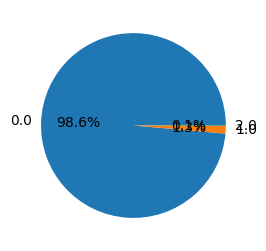

In [32]:
plt.figure(figsize=(4,3))
y_train.value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')  # To remove the y-label
print(y_train.value_counts())

### 4.1 Random Undersampling ###

CH
0.0    294
1.0    294
2.0    294
Name: count, dtype: int64


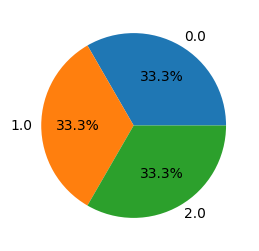

In [15]:
from imblearn.under_sampling import RandomUnderSampler

rus=RandomUnderSampler(sampling_strategy='auto')

# Perform the resampling
X_train_rus, y_train_rus = rus.fit_resample(X_train_mod,y_train)

plt.figure(figsize=(4,3))
# Plot the value counts of the resampled target variable as a pie chart
y_train_rus.value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')  # To remove the y-label
print(y_train_rus.value_counts())

# New undersampled dataset
training_df_US = pd.DataFrame(X_train_rus, columns=X_train_mod.columns)
training_df_US['CH'] = y_train_rus

### 4.2 SMOTE plus random undersampling ###

CH
0.0    1000
1.0    1000
2.0    1000
Name: count, dtype: int64


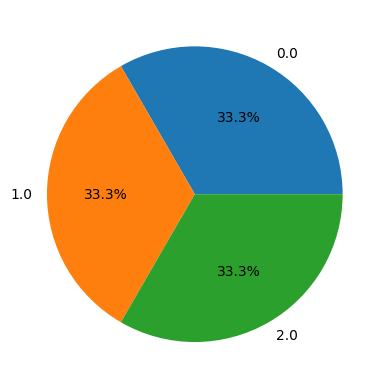

In [21]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter
from sklearn.datasets import make_classification

# Define SMOTE + Undersampling strategy
smote = SMOTE(sampling_strategy={2: 1000}, random_state=seed)  # Oversample only classes 2,4,5
undersample = RandomUnderSampler(sampling_strategy={0:1000, 1: 1000}, random_state=seed)  # Undersample majority classes 0,1,3

# Combine in a pipeline
resampling_pipeline = Pipeline([
    ('smote', smote),
    ('undersample', undersample)
])

X_train_res, y_train_res = resampling_pipeline.fit_resample(X_train_mod, y_train)


y_train_res.value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel('')  # To remove the y-label
print(y_train_res.value_counts())

# New undersampled dataset
training_df_RES = pd.DataFrame(X_train_res, columns=X_train_mod.columns)
training_df_RES['CH'] = y_train_res

## 5. MODEL ##

In [33]:
# Import libraries

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import LinearSVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, make_scorer, confusion_matrix, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier

from scipy.stats import randint, uniform

/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


### 5.1 Compare Models ###

In [34]:
# Define the classifiers to test
seed=345
clfs = [
    ('LogReg', LogisticRegression(max_iter=1000, multi_class='ovr', random_state=seed)),  # Logistic Regression supports multi-class
    ('KNN', KNeighborsClassifier()),  # KNN supports multi-class by default
    ('DT', DecisionTreeClassifier()),  # Decision Trees support multi-class
    ('RF', RandomForestClassifier(random_state=seed)),  # RF supports multi-class
    ('LinSVM', LinearSVC(random_state=seed, max_iter=1000, multi_class='ovr')),  # Explicitly set 'ovr' (default)
    ('XGB', XGBClassifier(random_state=seed, use_label_encoder=False, objective='multi:softmax')),  # Set objective for multi-class
    ('AdaB', AdaBoostClassifier(random_state=seed,algorithm="SAMME")),  # AdaBoost supports multi-class but weak learners should be set
    ('GradB', GradientBoostingClassifier(random_state=seed)),  # Supports multi-class
    ('Bagging', BaggingClassifier(random_state=seed)),  # Supports multi-class
    ('LGBM', LGBMClassifier(random_state=seed,objective='multiclass',num_class=3))
]

In [35]:
import pandas as pd
from imblearn.pipeline import Pipeline as ImbPipeline  # NOTE: Must use imblearn pipeline, not sklearn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score


seed =345

# 1. Setup Data
# IMPORTANT: Pass the ORIGINAL training data (X_train_mod, y_train). 
# Do NOT pass the resampled data (X_train_res) to the CV loop.
X = X_train_mod
y = y_train

# 2. Setup the Fixed Sampling Strategies
# Note: Ensure these counts (1000) are valid for your specific dataset counts.
# SMOTE will upsample Class 2 to 1000 samples.
smote_step = SMOTE(sampling_strategy={2: 1000}, random_state=seed) 

# Undersampler will downsample Class 0 and 1 to 1000 samples each.
undersample_step = RandomUnderSampler(sampling_strategy={0: 1000, 1: 1000}, random_state=seed)

# 3. Setup Cross-Validation
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
roc_auc_scorer = make_scorer(roc_auc_score, multi_class='ovr', needs_proba=True)
# needs_proba=False is the default, so cross_val_score will now use .predict()
#f1_macro_scorer = make_scorer(f1_score, average='macro')

results = {}

# 4. The Robust Loop
for clf_name, clf in clfs:
    if hasattr(clf, "predict_proba"):
        print(f"Evaluating {clf_name}...")
        
        # Create a pipeline for THIS specific classifier
        # The pipeline steps run sequentially: SMOTE -> Undersample -> Classifier
        # Because we use ImbPipeline, resampling occurs ONLY during 'fit', never during 'predict'
        model_pipeline = ImbPipeline([
            ('smote', smote_step),
            ('undersample', undersample_step),
            ('classifier', clf)
        ])
        
        # Run CV on the pipeline
        # The pipeline manages splitting X and y, then applying SMOTE only to the train portion
        try:
            cv_scores = cross_val_score(model_pipeline, X, y, cv=kf, scoring=roc_auc_scorer)
            results[clf_name] = cv_scores
        except ValueError as e:
            print(f"Skipping {clf_name} due to error: {e}")

# 5. Review Results
cv_scores_df = pd.DataFrame(results)


# Display Mean AUC and Standard Deviation (Stability)
summary = pd.DataFrame({
    'Mean OVR AUC': cv_scores_df.mean(),
    'Std Dev': cv_scores_df.std()
}).sort_values(by='Mean OVR AUC', ascending=False)
'''
summary = pd.DataFrame({
    'Mean F1 Macro': cv_scores_df.mean(),
    'Std Dev': cv_scores_df.std()
}).sort_values(by='Mean F1 Macro', ascending=False)
'''
print(summary)

/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Evaluating LogReg...


/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

Evaluating KNN...
Evaluating DT...
Evaluating RF...
Evaluating XGB...


/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:52:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:52:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:52:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [14:52:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not us

Evaluating AdaB...
Evaluating GradB...
Evaluating Bagging...
Evaluating LGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000471 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4862
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000473 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4857
[LightGBM] [Info] Number of data points in the train set: 3000, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612


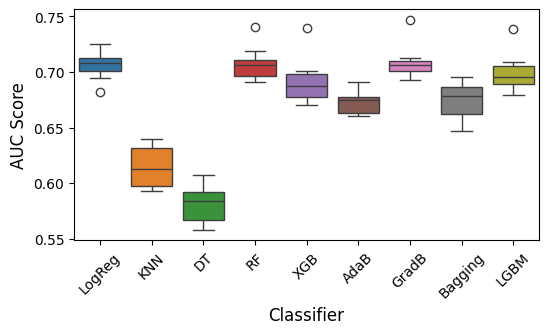

In [36]:
# Plot scores
fig, ax = plt.subplots(figsize=(6, 3))
sns.boxplot(data=cv_scores_df)

# Add axis labels
ax.set_xlabel('Classifier', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
#ax.set_title('Cross-Validation Scores for Different Classifiers', fontsize=14)

plt.xticks(rotation=45)
plt.savefig("figures/AUC_classifiers.png", dpi=300, bbox_inches='tight')
plt.show()

### 5.2 Random Forest ###

#### 5.2.1 Import datasets ####

In [37]:
training_df=pd.read_csv('training_df_3class.csv',usecols=lambda column: column != 'Unnamed: 0')
test_df=pd.read_csv('test_df_3class.csv', usecols=lambda column: column != 'Unnamed: 0')

training_df.head()

,Broad_ID,gene1,gene2,gene3,VAF1,VAF2,VAF3,sex,CH_score,eid,...,immret,hiscatret,age,year_of_assessment,year_MN,MN_type,CHRS,MN,giant_plt,CH
0,2242278,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,4676048.0,...,0.308,0.011,41.166667,2009.833333,NaN,NaN,0.0,0,0,0.0
1,2103093,DNMT3A,NaN,NaN,0.037,NaN,NaN,1,3.5,2137600.0,...,0.297,0.014,55.583333,2009.416667,NaN,NaN,7.5,0,0,0.0
2,2650421,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,4415008.0,...,0.273,0.019,58.083333,2009.916667,NaN,NaN,0.0,0,1,0.0
3,1273525,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,1865848.0,...,0.200,0.010,62.750000,2009.416667,NaN,NaN,0.0,0,1,0.0
4,3941600,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,4782905.0,...,0.391,0.035,48.333333,2009.416667,NaN,NaN,0.0,0,0,0.0


In [38]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369260 entries, 0 to 369259
Data columns (total 41 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Broad_ID            369260 non-null  int64  
 1   gene1               23170 non-null   object 
 2   gene2               1581 non-null    object 
 3   gene3               161 non-null     object 
 4   VAF1                23170 non-null   float64
 5   VAF2                1581 non-null    float64
 6   VAF3                161 non-null     float64
 7   sex                 369260 non-null  int64  
 8   CH_score            369260 non-null  float64
 9   eid                 369260 non-null  float64
 10  WBC                 369260 non-null  float64
 11  RBC                 369260 non-null  float64
 12  Hbconc              369260 non-null  float64
 13  haematocrit         369260 non-null  float64
 14  MCV                 369260 non-null  float64
 15  MCHb                369260 non-nul

In [39]:
# Drop these columns 
columns_to_drop=['Broad_ID','gene1','gene2','gene3','VAF1','VAF2','VAF3','CH_score','eid','WBC','haematocrit','PDW',
                 'hiscatret','year_of_assessment','CHRS','year_MN','MN_type','MN']

training_mod= training_df.drop(columns=columns_to_drop) 
test_mod=test_df.drop(columns=columns_to_drop) 
training_mod.head()

,sex,RBC,Hbconc,MCV,MCHb,MCHbconc,RDW,platelet,plateletcrit,MPV,...,eosinophil,basophil,nucRBC,reticulocyte,MRV,MspCV,immret,age,giant_plt,CH
0,1,4.956,14.94,88.12,30.14,34.21,12.55,211.1,0.194,9.23,...,0.08,0.04,0.0,0.036,109.83,79.09,0.308,41.166667,0,0.0
1,1,5.038,15.23,88.51,30.23,34.16,13.70,236.9,0.240,10.16,...,0.24,0.01,0.0,0.047,101.35,78.13,0.297,55.583333,0,0.0
2,1,4.922,14.49,89.40,29.44,32.93,13.08,151.4,0.133,8.82,...,0.07,0.02,0.0,0.068,109.48,78.74,0.273,58.083333,1,0.0
3,0,4.356,13.72,92.83,31.49,33.92,12.98,248.2,0.251,10.15,...,0.09,0.03,0.0,0.050,96.25,87.99,0.200,62.750000,1,0.0
4,0,4.029,12.35,89.42,30.65,34.28,17.99,197.5,0.182,9.22,...,0.45,0.05,0.0,0.091,127.59,94.23,0.391,48.333333,0,0.0


In [40]:
X_train_mod=training_mod.drop(columns=['CH'])
X_test_mod=test_mod.drop(columns=['CH'])
y_train=training_mod['CH']
y_test=test_mod['CH']

In [41]:
y_train.value_counts()

CH
0.0    364090
1.0      4876
2.0       294
Name: count, dtype: int64

In [42]:
X_train_mod.columns

Index(['sex', 'RBC', 'Hbconc', 'MCV', 'MCHb', 'MCHbconc', 'RDW', 'platelet',
       'plateletcrit', 'MPV', 'lymphocyte', 'monocyte', 'neutrophil',
       'eosinophil', 'basophil', 'nucRBC', 'reticulocyte', 'MRV', 'MspCV',
       'immret', 'age', 'giant_plt'],
      dtype='object')

#### 5.2.2 Run model with all predictors to find the best hyperparameters - random search ####

In [43]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, roc_auc_score, accuracy_score, classification_report,recall_score
from scipy.stats import randint

seed=345

# Define the hyperparameters to search for RandomForest
param_dist = {
    'n_estimators': randint(10, 300),  # Number of trees in the forest
    'max_depth': randint(1, 30),  # Maximum depth of the tree
    'min_samples_split': randint(2, 20),  # Minimum samples required to split a node
    'min_samples_leaf': randint(1, 20),  # Minimum samples required at a leaf node
    'max_features': ['log2'],            # Features to consider when looking for the best split
    'bootstrap': [True],                   # Whether bootstrap samples are used when building trees
    'criterion': ['gini'],                  # Function to measure the quality of a split
}

# Define a custom scoring function for multi-class AUC
roc_auc_scorer = make_scorer(roc_auc_score, multi_class='ovr', needs_proba=True)

recall_scorer = make_scorer(
    recall_score, 
    average='macro'   # or 'weighted', 'micro'
)


# Initialize RandomForest model
#model = RandomForestClassifier(random_state=seed)

# Initialize the BalancedRandomForest model
model = BalancedRandomForestClassifier(replacement=True, sampling_strategy='all', random_state=seed)


# Randomized Search over hyperparameters
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=500,  # Number of trials
    scoring=recall_scorer,  # Use roc_auc score for evaluation
    n_jobs=-1,  # Use all available cores
    cv=10,  # 10-fold cross-validation
    random_state=seed
)

# Fit the model on the training data
random_search.fit(X_train_mod, y_train)

# Best model after RandomizedSearchCV
best_model_RF = random_search.best_estimator_

# Print the best model parameters
print("Best Model Parameters:")
print(random_search.best_params_)

# Predictions on the test set
y_pred = best_model_RF.predict(X_test_mod)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Best Model Parameters:
{'bootstrap': True, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 12, 'min_samples_split': 18, 'n_estimators': 233}

Accuracy Score: 0.5607
Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.56      0.72     91024
         1.0       0.02      0.53      0.04      1219
         2.0       0.01      0.63      0.01        73

    accuracy                           0.56     92316
   macro avg       0.34      0.57      0.26     92316
weighted avg       0.98      0.56      0.71     92316



#### 5.2.3 Save Model ####

In [44]:
import pickle

features_list=X_train_mod.columns.to_list()

model_package= {
    "model": best_model_RF,
    "features": features_list
}

# Save the trained model
with open("3class_BRF_baseline_giantplt_latest.pkl", "wb") as f:
    pickle.dump(model_package, f)

print("Model saved successfully as 3class_BRF_baseline_giantplt_latest.pkl")

Model saved successfully as 3class_BRF_baseline_giantplt_latest.pkl


#### 5.2.4 Load model ####

In [9]:
import pickle
# Load the saved model and extract parameters
# -----------------------------------------------------------
print("--- Loading Model and Extracting Parameters ---")
with open("models/3class_BRF_baseline_giantplt.pkl", "rb") as f:
    loaded_package = pickle.load(f)

loaded_model = loaded_package['model']
best_params_RF = loaded_model.get_params()

--- Loading Model and Extracting Parameters ---


#### 5.2.5 ROC_AUC, threshold calculation ####

class, theshold, gmeans: 0 0.37721769774920016
class, theshold, gmeans: 1 0.3419687427773537
class, theshold, gmeans: 2 0.24145731011136348


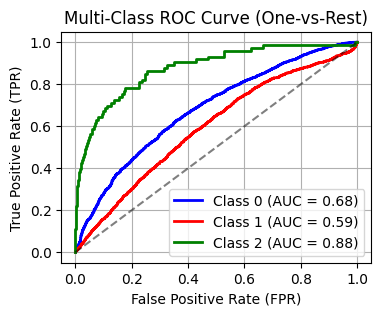

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

loaded_model.fit(X_train_mod,y_train)

# Binarize the labels for multi-class classification
n_classes = len(np.unique(y_test))  # Number of classes
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))  # Convert to one-hot encoding
y_pred_proba = loaded_model.predict_proba(X_test_mod)  # Get predicted probabilities for each class

# Plot ROC curve for each class
plt.figure(figsize=(4, 3))

colors = ['blue', 'red', 'green', 'brown']  # Adjust for more classes

for i in range(n_classes):
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])  # Compute ROC for class i
    roc_auc = auc(fpr, tpr)  # Compute AUC
    ix=np.argmax(tpr-fpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')
    print("class, theshold, gmeans:",i, thresholds[ix])

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Labels and legend
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()

#### 5.2.6 Precision- Recall ####

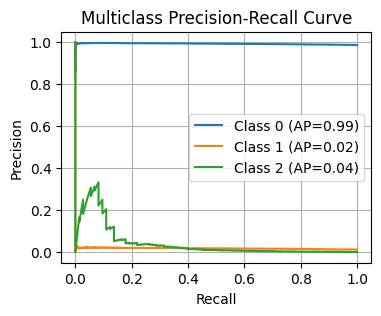

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score
#Compute Precision-Recall curves and Average Precision for each class
plt.figure(figsize=(4, 3))
for i in range(y_pred_proba.shape[1]):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    ap_score = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    
    plt.plot(recall, precision, label=f'Class {i} (AP={ap_score:.2f})')

# Plot formatting
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multiclass Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

#### 5.2.7 Confusion Matrix ####


--- Plotting Confusion Matrix ---


Text(0, 0.5, 'True Label')

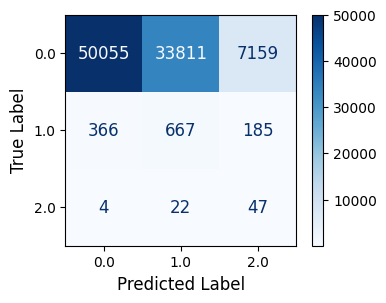

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, make_scorer, confusion_matrix
print("\n--- Plotting Confusion Matrix ---")
classes = np.unique(y_train)
n_classes = len(classes)
y_pred = loaded_model.predict(X_test_mod)
cmap = sns.color_palette("Blues", as_cmap=True)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

plt.figure(figsize=(4, 3))
ax = plt.gca()
disp.plot(cmap=cmap, ax=ax, values_format='d', text_kw={"fontsize": 12})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

## 6 SHAP ##

In [47]:
import shap
import pickle

# Load the saved model
with open("models/3class_BRF_giantplt_ASH_latest.pkl", "rb") as f:
    loaded_model_package = pickle.load(f)

loaded_model=loaded_model_package["model"]
loaded_features=loaded_model_package["features"]

# Train the model
loaded_model.fit(X_train_mod, y_train)

# Create SHAP explainer for the model
explainer = shap.Explainer(loaded_model.predict_proba, X_test_mod, check_additivity=False)

# Compute SHAP values
shap_values = explainer(X_test_mod)  # Returns an array of SHAP values (one per class)

/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
PermutationExplainer explainer: 92317it [6:59:44,  3.66it/s]                    


In [50]:
loaded_features

['RBC',
 'Hbconc',
 'MCV',
 'RDW',
 'platelet',
 'plateletcrit',
 'lymphocyte',
 'monocyte',
 'neutrophil',
 'eosinophil',
 'reticulocyte',
 'age',
 'giant_plt']

/var/folders/01/qxbg7rcx0ds_3w3r_82z10zh0000gn/T/ipykernel_56344/4220670606.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_class, X_test_mod,show=False)


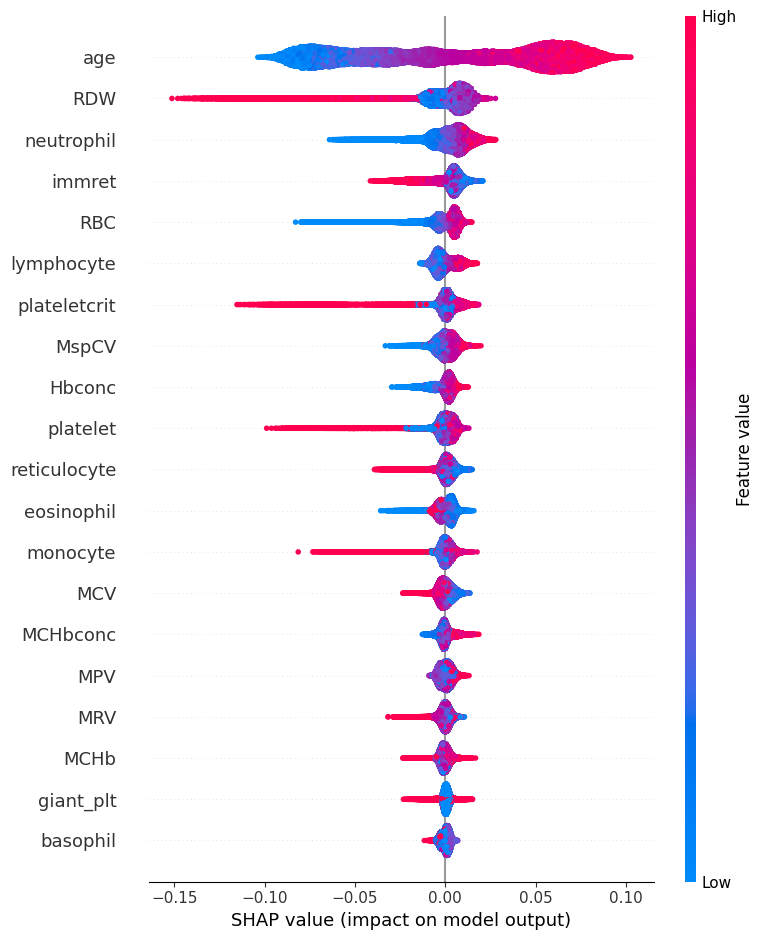

In [53]:
# Select the class to visualize (e.g., class 0)
class_index = 1  # Change this to visualize a different class
shap_values_class = shap_values[:, :, class_index]  # Extract SHAP values for the chosen class

# Set figure size
plt.rcParams["figure.figsize"] = [6, 4]

# Plot SHAP summary plot for the chosen class
shap.summary_plot(shap_values_class, X_test_mod,show=False)
plt.tight_layout()
plt.savefig("figures/shap_equivocal.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
for i in range(22):
    print(np.array(loaded_features)[i],abs(shap_values.values[:, i, 1]).max(),abs(shap_values.values[:, i, 2]).max())
    if((abs(shap_values.values[:, i, 1]).max()<0.05)&(abs(shap_values.values[:, i, 2]).max()<0.05)):
        print("Insignificant feature")

sex 0.006731349278304686 0.012169146480619559
Insignificant feature
RBC 0.07902181167142643 0.1364002484499075
Hbconc 0.03893042489571772 0.03658208242982352
Insignificant feature
MCV 0.04842247678178251 0.0734468841537948
MCHb 0.02447352503768564 0.05562740228847543
MCHbconc 0.019983389200465995 0.016698111073642368
Insignificant feature
RDW 0.15716768810703094 0.3137568765391452
platelet 0.1370954085215674 0.28306214707671257
plateletcrit 0.12980947435325063 0.2538629656779183
MPV 0.019951147704674866 0.01882915709790278
Insignificant feature
lymphocyte 0.03131815133607081 0.04037924202199374
Insignificant feature
monocyte 0.05534677955164286 0.1417763938753476
neutrophil 0.059686506469410656 0.09494078161471574
eosinophil 0.039148959211683015 0.0931157954942985
basophil 0.02375792775433615 0.017318577080480534
Insignificant feature
nucRBC 0.0 0.0
Insignificant feature
reticulocyte 0.0326830663389245 0.05655651474538546
MRV 0.04948205114843238 0.0819605586378088
MspCV 0.0343443609675

## 7. BORUTA ##

### To see if SHAP and BORUTA give consistent insignificant features ###

In [4]:
from boruta import BorutaPy
from imblearn.ensemble import BalancedRandomForestClassifier
import pickle

# Load the saved model
with open("models/3class_BRF_baseline_giantplt_latest.pkl", "rb") as f:
    loaded_model_package = pickle.load(f)

loaded_model=loaded_model_package["model"]
loaded_features=loaded_model_package["features"]

training_df=pd.read_csv('training_df_3class.csv',index_col=0)
test_df=pd.read_csv('test_df_3class.csv',index_col=0)
training_df.head()

cols_to_keep=['sex','RBC','Hbconc', 'MCV','MCHb','MCHbconc', 'RDW', 'platelet', 'plateletcrit', 'MPV',
              'lymphocyte','monocyte', 'neutrophil', 'eosinophil','basophil','nucRBC', 'reticulocyte', 'MRV','MspCV',
              'immret','age','giant_plt','CH']
#cols_to_keep=['MCV','MCHb', 'platelet', 'PDW','lymphocyte','monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'age','CHRS','CH']

training_df_boruta=training_df[cols_to_keep]
test_df_boruta=test_df[cols_to_keep]

X_train=training_df_boruta.drop(columns=['CH'])
y_train=training_df_boruta[['CH']]
X_test=training_df_boruta.drop(columns=['CH'])
y_test=training_df_boruta[['CH']]

In [7]:
X_train.columns

Index(['sex', 'RBC', 'Hbconc', 'MCV', 'MCHb', 'MCHbconc', 'RDW', 'platelet',
       'plateletcrit', 'MPV', 'lymphocyte', 'monocyte', 'neutrophil',
       'eosinophil', 'basophil', 'nucRBC', 'reticulocyte', 'MRV', 'MspCV',
       'immret', 'age', 'giant_plt'],
      dtype='object')

In [10]:
print("X_train shape:", X_train.shape)

X_train shape: (369260, 22)


In [5]:
model=loaded_model
seed=345

# Initialize Boruta
boruta_selector = BorutaPy(estimator=model, verbose=2, max_iter= 100, random_state=seed)

# Fit Boruta
boruta_selector.fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[boruta_selector.support_].tolist()
print("\n✅ Selected Features by Boruta:")
print(selected_features)

# Optionally, get ranking of all features
feature_ranks = list(zip(X_train.columns, boruta_selector.ranking_))
feature_ranks.sort(key=lambda x: x[1])  # Sort by importance
print("\n📊 Feature Rankings:")
for feature, rank in feature_ranks:
    print(f"{feature}: Rank {rank}")

/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	22
Rejected: 	0


/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	22
Rejected: 	0


/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


...

Iteration: 	27 / 100
Confirmed: 	17
Tentative: 	1
Rejected: 	4


/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Iteration: 	28 / 100
Confirmed: 	17
Tentative: 	1
Rejected: 	4


/Users/riyanandi/Desktop/UKBB/myenv/lib/python3.9/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Iteration: 	29 / 100
Confirmed: 	17
Tentative: 	0
Rejected: 	5


BorutaPy finished running.

Iteration: 	30 / 100
Confirmed: 	17
Tentative: 	0
Rejected: 	5

✅ Selected Features by Boruta:
['RBC', 'Hbconc', 'MCV', 'MCHb', 'RDW', 'platelet', 'plateletcrit', 'lymphocyte', 'monocyte', 'neutrophil', 'eosinophil', 'reticulocyte', 'MRV', 'MspCV', 'immret', 'age', 'giant_plt']

📊 Feature Rankings:
RBC: Rank 1
Hbconc: Rank 1
MCV: Rank 1
MCHb: Rank 1
RDW: Rank 1
platelet: Rank 1
plateletcrit: Rank 1
lymphocyte: Rank 1
monocyte: Rank 1
neutrophil: Rank 1
eosinophil: Rank 1
reticulocyte: Rank 1
MRV: Rank 1
MspCV: Rank 1
immret: Rank 1
age: Rank 1
giant_plt: Rank 1
MCHbconc: Rank 2
MPV: Rank 3
basophil: Rank 4
sex: Rank 5
nucRBC: Rank 6


In [15]:
print([attr for attr in dir(boruta_selector) if 'shadow' in attr.lower() or 'hit' in attr.lower()])

['_add_shadows_get_imps', '_assign_hits']


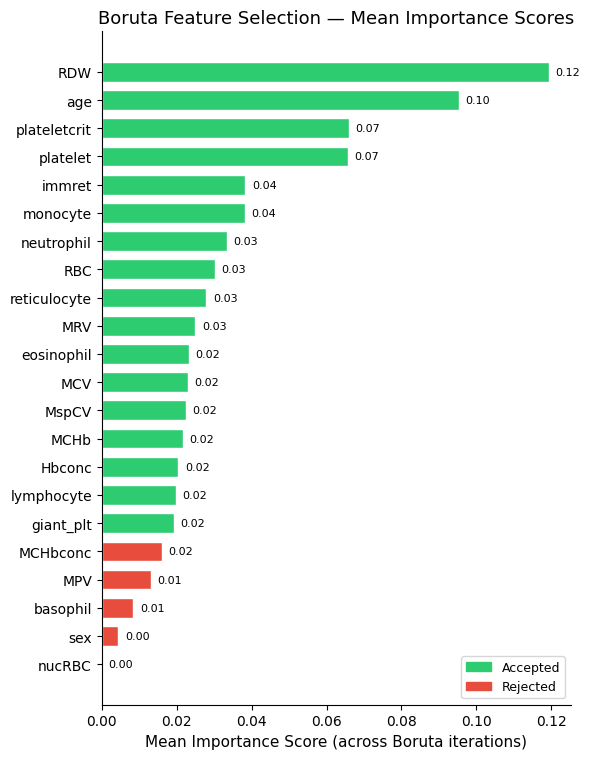

In [26]:
import matplotlib.patches as mpatches

n_features = X_train.shape[1]
imp_history = boruta_selector.importance_history_  # shape: (30, 22)

# Mean importance across iterations per feature
mean_z = np.nanmean(imp_history, axis=0)

z_df = pd.DataFrame({
    'feature': X_train.columns,
    'mean_z': mean_z,
})
z_df['status'] = 'Rejected'
#z_df.loc[boruta_selector.support_weak_, 'status'] = 'Tentative'
z_df.loc[boruta_selector.support_, 'status'] = 'Accepted'
z_df = z_df.sort_values('mean_z', ascending=True)

#color_map = {'Accepted': '#2ecc71', 'Tentative': '#f39c12', 'Rejected': '#e74c3c'}
color_map = {'Accepted': '#2ecc71', 'Rejected': '#e74c3c'}
colors = z_df['status'].map(color_map)

fig, ax = plt.subplots(figsize=(6, max(6, len(z_df) * 0.35)))
bars = ax.barh(z_df['feature'], z_df['mean_z'], color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, z_df['mean_z']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha='center', fontsize=8)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

ax.set_xlabel('Mean Importance Score (across Boruta iterations)', fontsize=11)
ax.set_title('Boruta Feature Selection — Mean Importance Scores', fontsize=13)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("figures/borutascores.png", dpi=300, bbox_inches='tight')
plt.show()